<a href="https://colab.research.google.com/github/lilianabs/kaggle-tools/blob/main/Messy_dataset_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(42)
n = 2000

# Target
y = np.random.binomial(1, 0.5, n)

# ===== NUMERICAL FEATURES =====

# Strong signal
num_strong = np.where(y == 1,
                      np.random.normal(2, 1, n),
                      np.random.normal(-2, 1, n))

# Weak signal
num_weak = np.where(y == 1,
                    np.random.normal(0.5, 1.5, n),
                    np.random.normal(0, 1.5, n))

# Noise
num_noise = np.random.normal(0, 1, n)

# Correlated features
num_corr1 = num_strong + np.random.normal(0, 0.2, n)
num_corr2 = num_strong * 0.8 + np.random.normal(0, 0.3, n)

# ===== CATEGORICAL FEATURES =====

# Strong categorical signal
cat_strong = np.where(y == 1,
                      np.random.choice(["A", "B"], n, p=[0.2, 0.8]),
                      np.random.choice(["A", "B"], n, p=[0.8, 0.2]))

# Weak categorical signal
cat_weak = np.where(y == 1,
                    np.random.choice(["X", "Y"], n, p=[0.45, 0.55]),
                    np.random.choice(["X", "Y"], n, p=[0.55, 0.45]))

# Noise categorical
cat_noise = np.random.choice(["K", "L", "M"], n)

# High-cardinality (dangerous)
cat_high_card = ["id_" + str(i) for i in range(n)]

# Rare category trap
cat_rare = np.random.choice(["R1", "R2", "R3"], n, p=[0.49, 0.49, 0.02])
cat_rare[y == 1][:10] = "R3"  # inject fake strong signal

df = pd.DataFrame({
    "target": y,
    "num_strong": num_strong,
    "num_weak": num_weak,
    "num_noise": num_noise,
    "num_corr1": num_corr1,
    "num_corr2": num_corr2,
    "cat_strong": cat_strong,
    "cat_weak": cat_weak,
    "cat_noise": cat_noise,
    "cat_high_card": cat_high_card,
    "cat_rare": cat_rare
})




In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   target         2000 non-null   int64  
 1   num_strong     2000 non-null   float64
 2   num_weak       2000 non-null   float64
 3   num_noise      2000 non-null   float64
 4   num_corr1      2000 non-null   float64
 5   num_corr2      2000 non-null   float64
 6   cat_strong     2000 non-null   object 
 7   cat_weak       2000 non-null   object 
 8   cat_noise      2000 non-null   object 
 9   cat_high_card  2000 non-null   object 
 10  cat_rare       2000 non-null   object 
dtypes: float64(5), int64(1), object(5)
memory usage: 172.0+ KB


# Numerical features

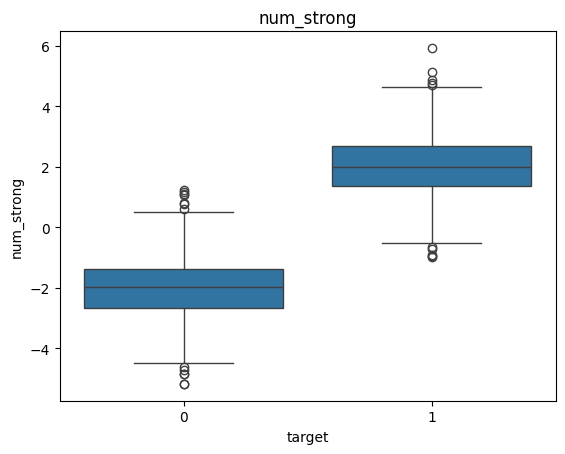

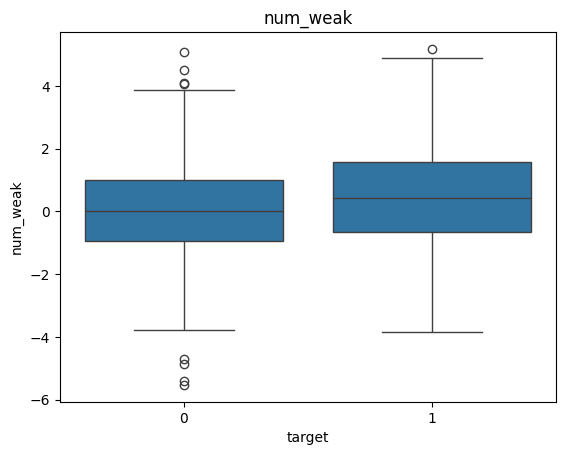

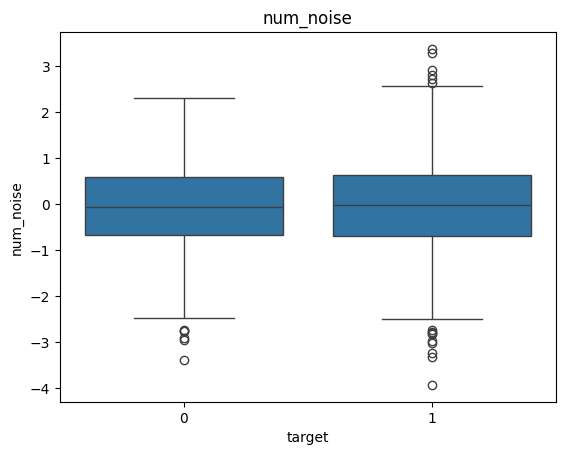

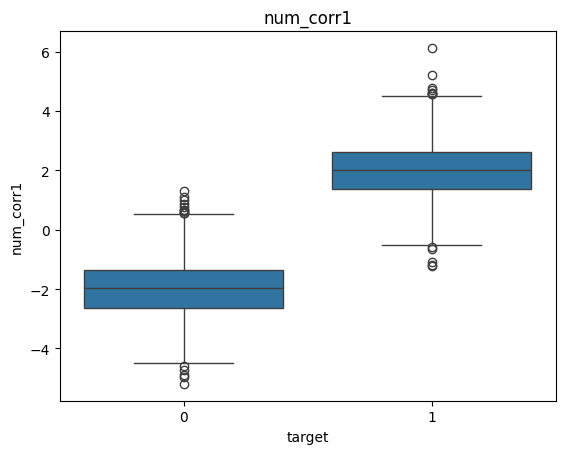

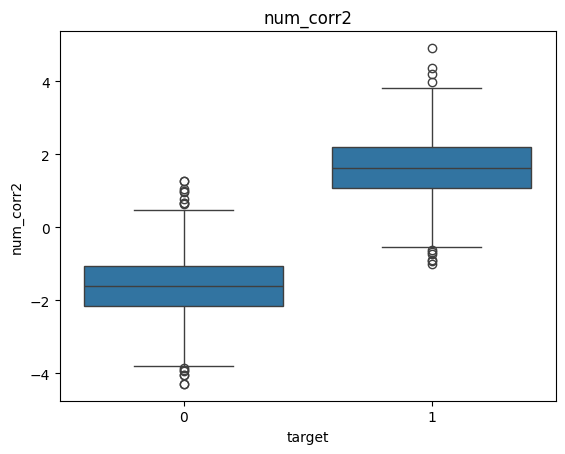

In [39]:
for col in ["num_strong", "num_weak", "num_noise", "num_corr1", "num_corr2"]:
    sns.boxplot(x="target", y=col, data=df)
    plt.title(col)
    plt.show()

Generating histograms for numerical features per class...


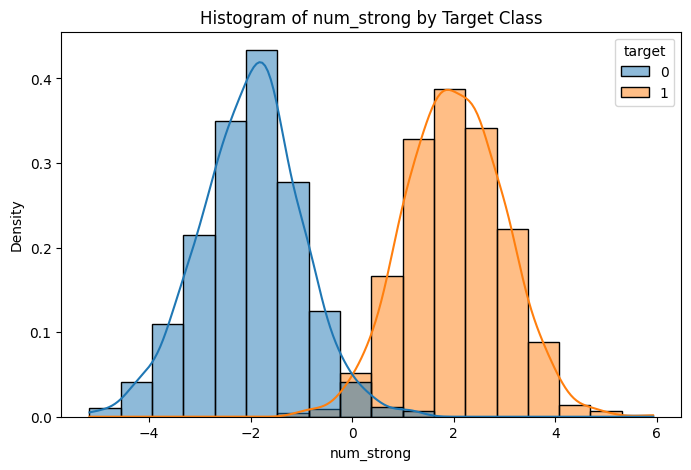

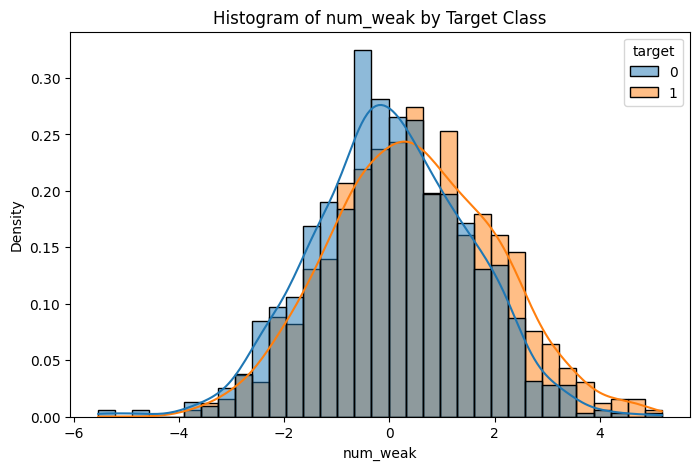

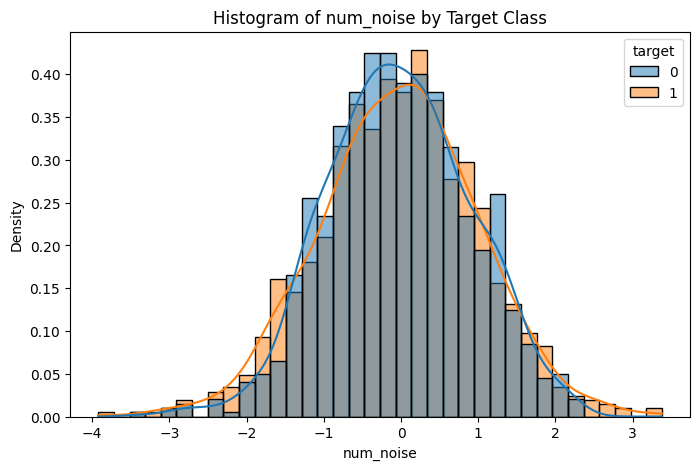

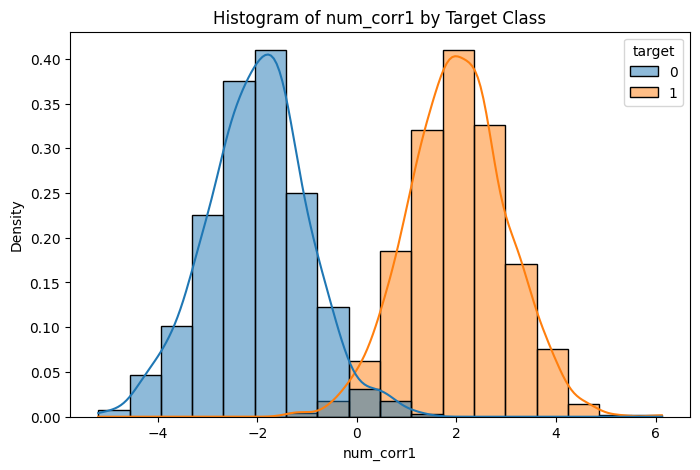

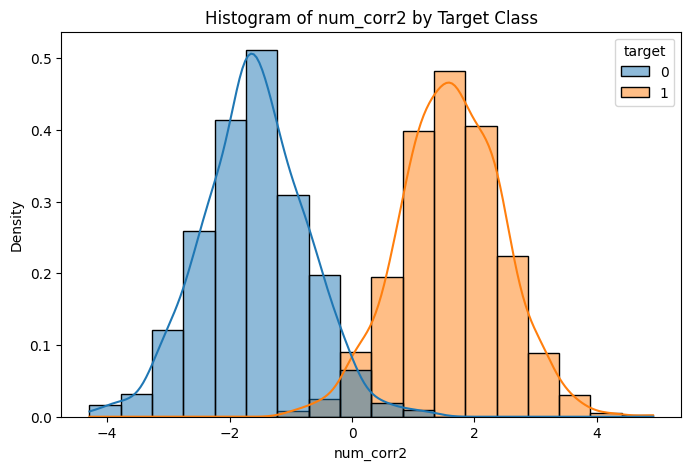

Histograms generated.


In [40]:
# Histograms per class for numerical features
print("Generating histograms for numerical features per class...")
numerical_cols = ["num_strong", "num_weak", "num_noise", "num_corr1", "num_corr2"]
for col in numerical_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=col, hue="target", kde=True, common_norm=False, stat="density")
    plt.title(f"Histogram of {col} by Target Class")
    plt.show()
print("Histograms generated.")

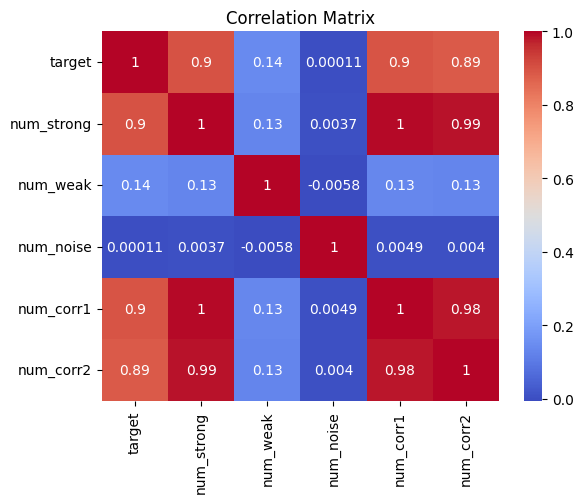

In [41]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

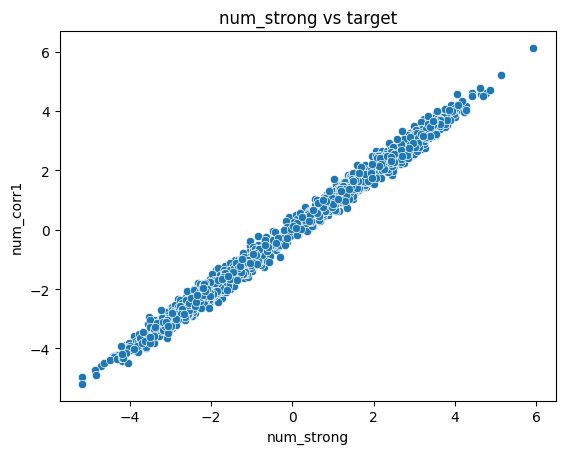

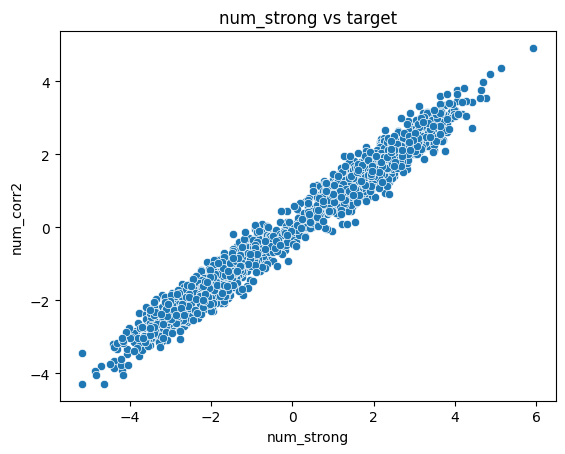

In [42]:
sns.scatterplot(x=df["num_strong"], y=df["num_corr1"])
plt.title("num_strong vs target")
plt.show()

sns.scatterplot(x=df["num_strong"], y=df["num_corr2"])
plt.title("num_strong vs target")
plt.show()

## Categorical features

In [43]:
for col in ["cat_strong", "cat_weak", "cat_noise", "cat_high_card", "cat_rare"]:
  print(f"Col {col}")
  print(pd.crosstab(df[col], df["target"], normalize="index"))

Col cat_strong
target             0         1
cat_strong                    
A           0.796046  0.203954
B           0.213667  0.786333
Col cat_weak
target           0         1
cat_weak                    
X         0.539920  0.460080
Y         0.446894  0.553106
Col cat_noise
target            0         1
cat_noise                    
K          0.500761  0.499239
L          0.507205  0.492795
M          0.471495  0.528505
Col cat_high_card
target           0    1
cat_high_card          
id_0           1.0  0.0
id_1           0.0  1.0
id_10          1.0  0.0
id_100         1.0  0.0
id_1000        1.0  0.0
...            ...  ...
id_995         1.0  0.0
id_996         0.0  1.0
id_997         1.0  0.0
id_998         0.0  1.0
id_999         1.0  0.0

[2000 rows x 2 columns]
Col cat_rare
target           0         1
cat_rare                    
R1        0.516785  0.483215
R2        0.473469  0.526531
R3        0.405405  0.594595


In [44]:
# Baseline model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

X = df.drop(columns=["target"])
y = df["target"]

cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(include="number").columns

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", "passthrough", num_cols)
])

model = Pipeline([
    ("prep", preprocess),
    ("clf", RandomForestClassifier())
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model.fit(X_train, y_train)

preds = model.predict_proba(X_test)[:, 1]
roc_auc_score(y_test, preds)

np.float64(0.9987739831643874)

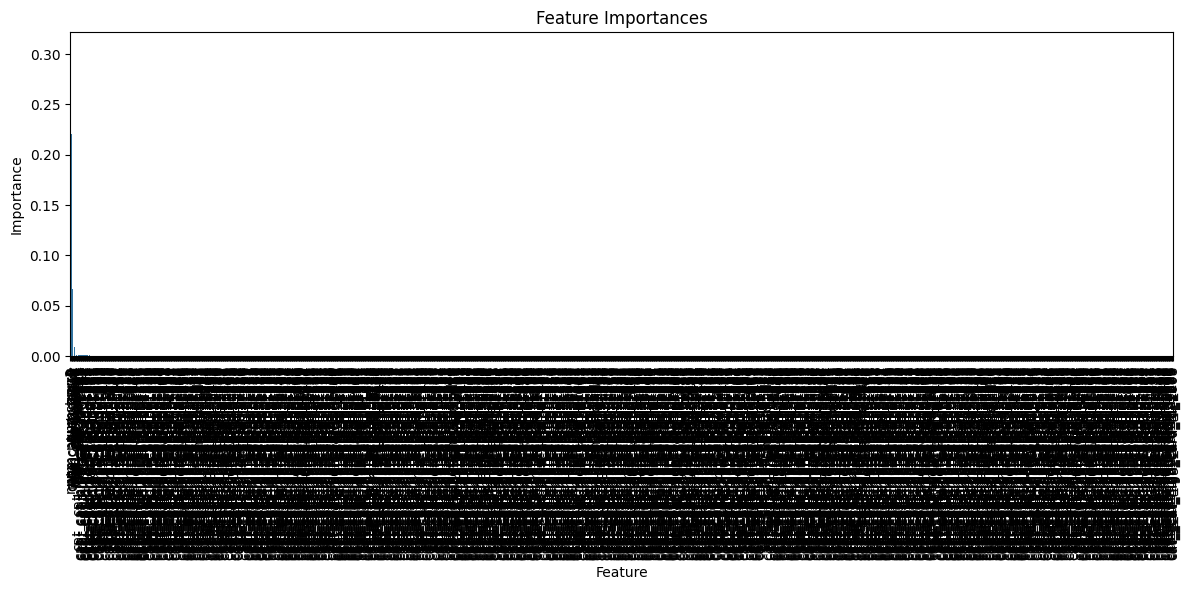

In [45]:
importances = model.named_steps["clf"].feature_importances_
feature_names = model.named_steps['prep'].get_feature_names_out()
feature_importances = pd.Series(importances, index=feature_names)

# Sort feature importances for better visualization
sorted_importances = feature_importances.sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=sorted_importances.index, y=sorted_importances.values)
plt.xticks(rotation=90)
plt.title('Feature Importances')
plt.ylabel('Importance')
plt.xlabel('Feature')
plt.tight_layout()
plt.show()

In [46]:
cat_cols = cat_cols.drop(["cat_high_card", "cat_rare"])
num_cols = num_cols.drop(["num_corr2", "num_corr1"])

In [47]:
X = df.drop(columns=["target"])
y = df["target"]

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", "passthrough", num_cols)
])

model = Pipeline([
    ("prep", preprocess),
    ("clf", RandomForestClassifier())
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model.fit(X_train, y_train)

preds = model.predict_proba(X_test)[:, 1]
roc_auc_score(y_test, preds)

np.float64(0.9981742697078831)

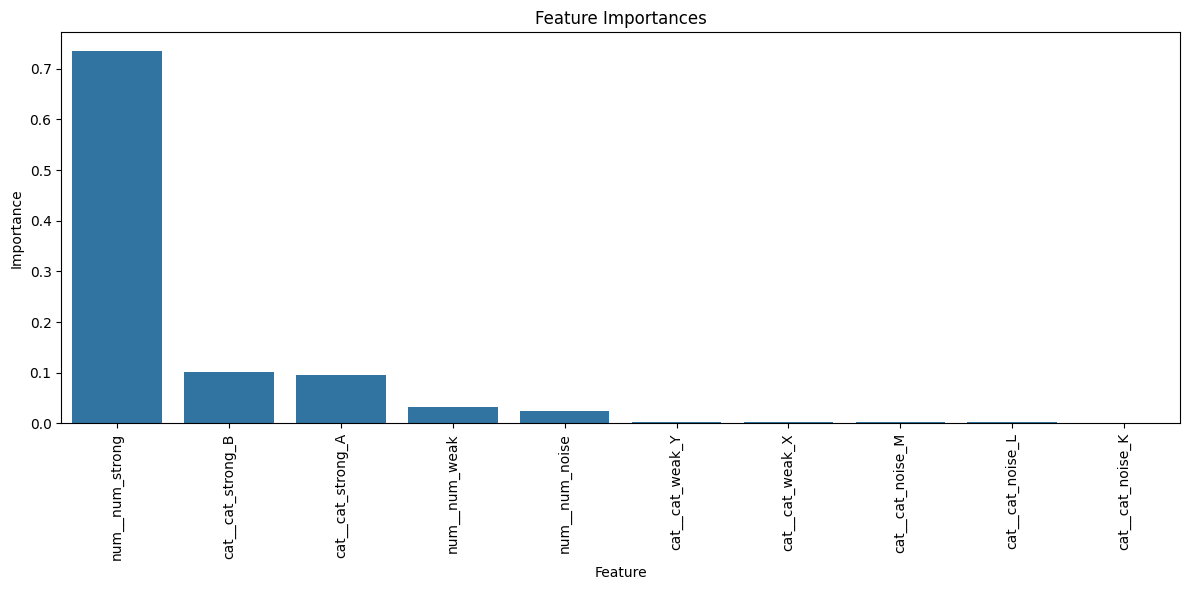

In [48]:
importances = model.named_steps["clf"].feature_importances_
feature_names = model.named_steps['prep'].get_feature_names_out()
feature_importances = pd.Series(importances, index=feature_names)

# Sort feature importances for better visualization
sorted_importances = feature_importances.sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=sorted_importances.index, y=sorted_importances.values)
plt.xticks(rotation=90)
plt.title('Feature Importances')
plt.ylabel('Importance')
plt.xlabel('Feature')
plt.tight_layout()
plt.show()